# Data Visualization Ethics Challenge

In this activity, you’ll work with a simple dataset and examine two deliberately bad charts.  
Each one ignores multiple best practices for ethical and effective visualization.

Your job is to:

1. Review each chart and note at least three issues you see.  
2. Create a new chart (or charts) that present the data clearly, accurately, and honestly.  
3. Include clear labels, a cited data source, and a descriptive but neutral title.

**Remember:** Strong visualizations tell the truth, provide context, and avoid design choices that distort or mislead.


## Step 1: Load the dataset

We’re using a provided CSV file with fictional sales data for a coffee chain.  
No need to modify anything in this cell — just run it so the dataset loads into your notebook.  
Once loaded, take a quick look at the first few rows to get familiar with the columns and values.


In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

coffee_df = pd.read_csv("fake_coffee_chain_sales.csv")
coffee_df.head()

,Year,Month,Region,Category,Sales,Profit
0,2020,January,East,Espresso,14724,5290.46
1,2020,January,East,Lattes,11948,4138.77
2,2020,January,East,Tea,18660,5959.44
3,2020,January,East,Pastries,11265,2604.46
4,2020,January,East,Beans,8954,2613.22


## Step 2: Review the BAD Charts

Below are two deliberately poor visualizations.  
Your task: Carefully review each and take notes on what you think is wrong, misleading, or just poorly designed.  
Think about chart type, colors, scales, labeling, and whether the chart tells the truth.  


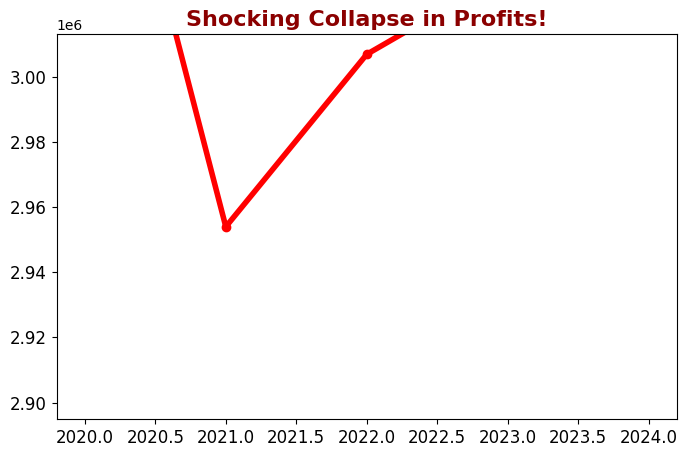

In [71]:
plt.figure(figsize=(8,5))
subset = coffee_df.groupby("Year")["Sales"].sum().reset_index()

# Wrong variable for title, truncated y-axis, misleading color & framing
plt.plot(subset["Year"], subset["Sales"], color="red", linewidth=4, marker="o")
plt.ylim(subset["Sales"].min() * 0.98, subset["Sales"].min() * 1.02)  # extreme truncation
plt.title("Shocking Collapse in Profits!", fontsize=16, fontweight="bold", color="darkred")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


In [72]:
coffee_df['Sales'].describe()

count     1200.00000
mean     12761.34000
std       4534.21934
min       4272.00000
25%       8967.50000
50%      12742.50000
75%      16400.50000
max      24873.00000
Name: Sales, dtype: float64

### Write your notes about bad chart #1 here:
(double click to open this markdown cell and type into it)


• Color choice is bad

•Title states "Collapse in Profits" but graph shows an increase, title could be updated to "Collapse in Profits durring 2020.5 to 2021", Title suggest a complete decline in sales over the whole data, though the data does not show that

•You can see that the y axis is supposed to be sales in the code, however the graph does not show that. If I was a passerbyer and did not have access to the data sheet or the code, I would be unaware that the y axis was sales. And same with the x axis

• Title mentions profits but code shows it is grouped by sales 

•The graph cuts off much of the data, in the code the y values (Sales) is having its min and max values trunacated, whith the values supposed to show sales, you would want to remove any truncation to allow the data to be truthfully shown 

• The graph needs to be cleaned up, the font size for the x and y are too big in comparison with the title(though its not the same size, due to the figsize it makes it feel squished together), colors should be changed from red and dark red (it feels aggressive but with no direction), the points on the line plot should not be the exact color as the line(this causes it to run together and not be easy to read)

• Top and right spines could be removed for easier visablity 

•y lable should be changed, unfortunately the data does not show if the ammount is in USD, CAD or other forms of currancy if you where to keep the titles message of profit per year, it would be better given this to completey change the title 





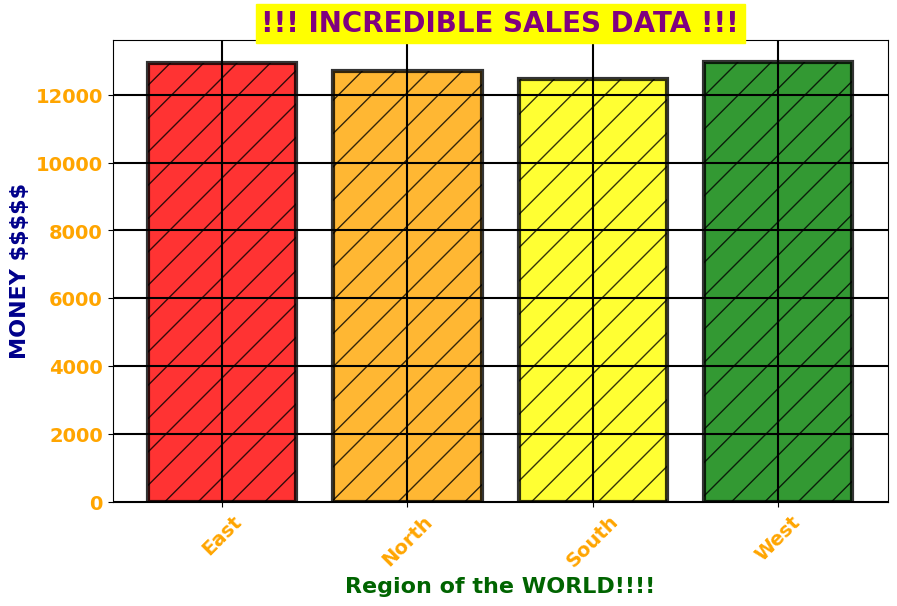

In [73]:
plt.figure(figsize=(10,6))
avg_sales = coffee_df.groupby("Region")["Sales"].mean().reset_index()

colors = ["red","orange","yellow","green","blue","purple"]

plt.bar(avg_sales["Region"], avg_sales["Sales"], 
        color=colors, edgecolor="black", linewidth=3, hatch="/", alpha=0.8)
plt.title("!!! INCREDIBLE SALES DATA !!!", fontsize=20, fontweight="bold", color="purple", backgroundcolor="yellow")
plt.grid(True, which='both', color='black', linestyle='-', linewidth=1.5)
plt.xlabel("Region of the WORLD!!!!", fontsize=16, fontweight="bold", color="darkgreen")
plt.ylabel("MONEY $$$$$", fontsize=16, fontweight="bold", color="darkblue")
plt.xticks(rotation=45, fontsize=14, fontweight="bold", color="orange")
plt.yticks(fontsize=14, fontweight="bold", color="orange")
plt.show()


### Write your notes about bad chart #2 here:
(double click to open this markdown cell and type into it)


• The grid is not needed 

• color pallet achive no coherrent message 

• The message the Data is trying to diplay is sales per region 

• Title should be changed to something like Sales per Region 

• y label says money but the data shows it is amount of sales not the sum of what has been sold per item 

• I would remove the highlight from the title

• Same as before I would change the figsize as the graph seems squished 

• x lable also needs changed, perhaps to just region  


## Step 3: Your Turn – Make It Right

Now it’s your turn to fix things.  

- Start by thinking about a question you want to answer with this dataset.  
- Choose a visualization type that matches your question and the data structure.  
- Apply the best practices from our lessons: clear labeling, appropriate scale, purposeful color, simplicity, and accessibility.  
- Be honest - don’t manipulate the chart to make a point that the data doesn’t support.  

When you’re done, add your chart(s) below. You may create more than one if it helps tell the story better.  


In [74]:
coffee_df['Sales'].describe()

count     1200.00000
mean     12761.34000
std       4534.21934
min       4272.00000
25%       8967.50000
50%      12742.50000
75%      16400.50000
max      24873.00000
Name: Sales, dtype: float64

In [75]:
coffee_df['Year'].head()

0    2020
1    2020
2    2020
3    2020
4    2020
Name: Year, dtype: int64

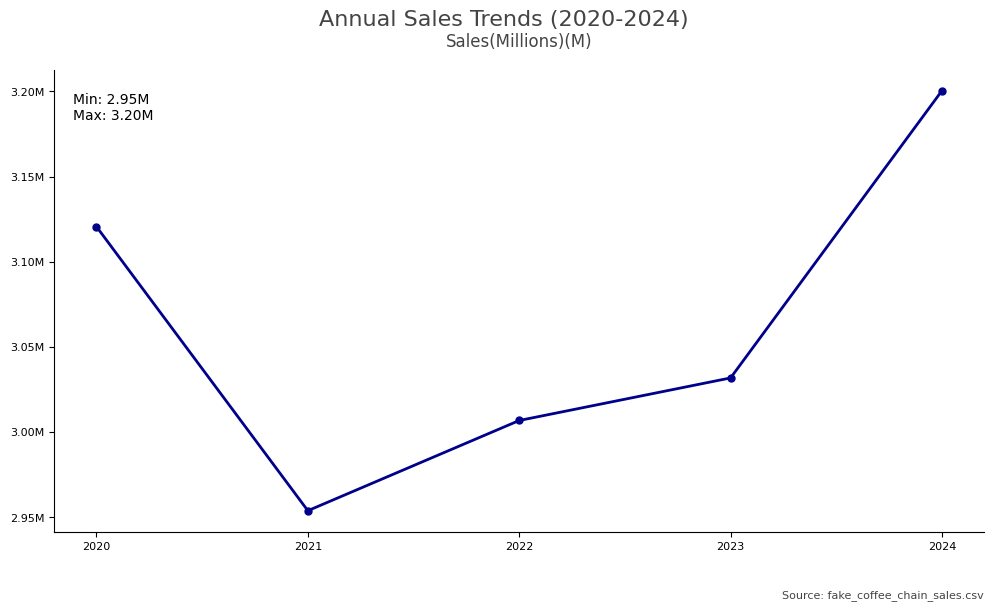

In [85]:
# Your GOOD visualization(s) here

subset = coffee_df.groupby("Year")["Sales"].sum().reset_index()

fig, ax =  plt.subplots(figsize=(12,6))

colors = ["darkblue","#444444", ]
ax.plot(subset["Year"], subset["Sales"], color="darkblue", linewidth=2, marker="o", markersize=5)

y_min = subset['Sales'].min()
y_max = subset['Sales'].max()

fig.suptitle("Annual Sales Trends (2020-2024)", fontsize=16, color="#444444", ha="center", va="top")
ax.text(.5, 1.08,"Sales(Millions)(M)",transform=ax.transAxes,ha="center", fontsize=12, color="#444444", va="top")
ax.text(0.02, 0.95, f"Min: {y_min/1e6:.2f}M\nMax: {y_max/1e6:.2f}M",transform=ax.transAxes, va='top')
ax.text(1.0, -0.15, "Source: fake_coffee_chain_sales.csv",transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8, color="#444444")

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos :f"{x/1e6:.2f}M"))
ax.set_xticks(subset["Year"])
ax.tick_params(axis='both', labelsize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)




plt.show()

The first thing I wanted to change about the line plot was the title. As mentioned before in the markdown, the old title was "Shocking Collapse in Profits!". The colums from the dataset that where used in the .groupby() where 'Year' and 'Sales'. The data via that .groupby() was trying to show Sales per Year. I settled on Annual Sale Trends(2020-2024) as it is a bit more descriptive and more in line with the data being displayed.  I then wanted to change the scientific notation on the y axis so I imported the ticker from matplotlib and formatted the ticks with a lambda function, as I didn't need the funciton else where so i did not define it. I then wanted to change the font of the x and y axis as it was big and felt crowded. I then changed the x axis from matplotlibs default formating as it was adding in .5 to the years although it was unneeded. 

In [77]:
avg_sales.describe()

,Sales
count,4.000000
mean,12761.340000
std,240.387318
min,12451.780000
25%,12632.685000
50%,12808.181667
75%,12936.836667
max,12977.216667


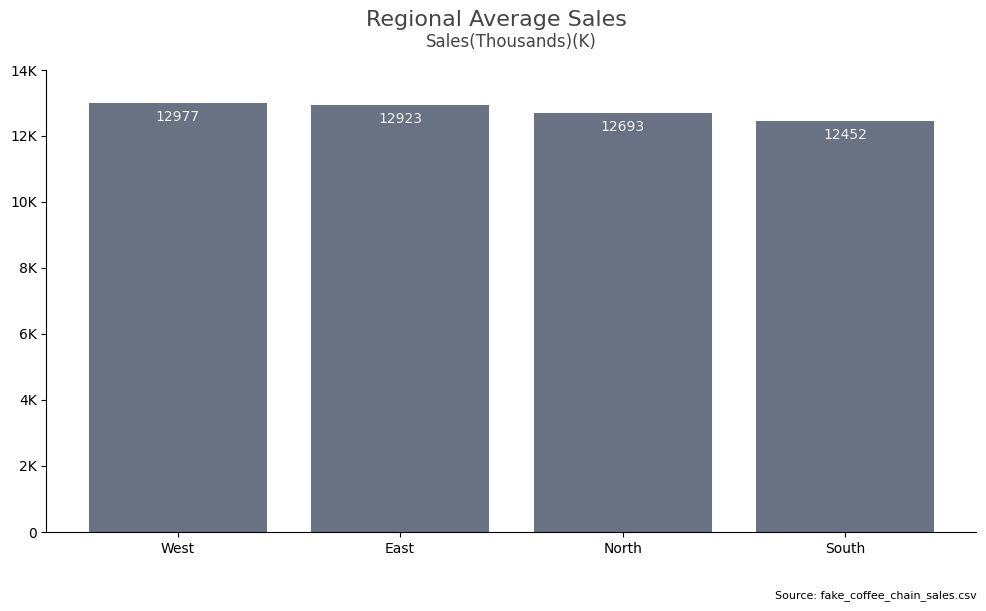

In [111]:
fig, ax = fig, ax =  plt.subplots(figsize=(12,6))

avg_sales = coffee_df.groupby("Region")["Sales"].mean().reset_index().sort_values("Sales", ascending=False)
bars = ax.bar(avg_sales["Region"], avg_sales["Sales"], color="#697283")
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() /2,
        height - 200,
        f"{height:.0f}",
        ha="center", va="top",
        color="#F0F0F0"
    )

fig.suptitle("Regional Average Sales", fontsize=16, color="#444444", ha="center", va="top")
ax.text(.5, 1.08,"Sales(Thousands)(K)",transform=ax.transAxes, ha="center", fontsize=12, color="#444444", va="top")

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos :'0' if x == 0 else f"{x/1e3:.0f}K"))
ax.set_ylim(0,14000)



ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(1.0, -0.15, "Source: fake_coffee_chain_sales.csv",transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8, color="#000000")

plt.show()

The original graph had much chart junk and wild colors.I removed the grid, the colors list, and the title immediately. The grid was just distracting and not showing any use in the data. I then changed the colors to a more neutral look. The title had no relavance to the data, as the data was showing sales per region I changed the title to Regional Average Sales and provided a subtitle to show sales being thousands. I then created a for loop to show each regions average sales in the bars themselves as I found it dificult to read exactly how much the sales where. I wanted to give exact numbers because the average sales are fairly close in number and I did not want to overcrowd the y axis with more ticks. I also shorten the ticks on the y axis from their full number to better minamize the y axis. I used the same lambda function but motified it to change to thousands rather than millions. I also added a condition to keep 0 as 0 instead of the function applying the string "K" to all ticks.